# **02 - Exploratory Analysis**

**Purpose:**  
This notebook explores trends, distributions, and inequalities in respiratory admissions using the cleaned and filtered spell-level dataset (`apc_clean.parquet`).  

I will examine:

- Overall admissions trends and seasonal patterns
- Length of stay distributions
- Demographic breakdowns (age, sex, ethnicity, deprivation)
- Inequalities in outcomes by deprivation and ethnicity
- Respiratory subgroup patterns (Asthma, COPD, Pneumonia, Other)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plt.style.use("seaborn-v0_8-whitegrid")
# pd.options.display.float_format = "{:,.2f}".format

# Load cleaned data
df = pd.read_parquet("../data/processed/apc_clean.parquet")
print(df.shape)
df.head()


(145305, 16)


,patient_id,adm,dis,n_episodes,los_days,any_emerg,imd_quintile,primary_diag,ethnicity,sex,age,spell_id,ethnicity_group,age_band_quinary,is_respiratory,respiratory_group
0,TEST5R6RIwmqlGSuQsuH3XEDEPIpC6uP,2020-07-07,2020-08-27,1,52.0,True,3,J181,Z,2,33,TEST5R6RIwmqlGSuQsuH3XEDEPIpC6uP|2020-07-07|20...,Not stated,30-34,True,Pneumonia
1,TESTBvWCMfXeov6a2sN2DtRFRfAAHxfs,2020-08-17,2020-08-20,1,4.0,False,1,J459,A,2,60,TESTBvWCMfXeov6a2sN2DtRFRfAAHxfs|2020-08-17|20...,White,60-64,True,Asthma
2,TESTqbToEEYKTHUco7WkMkyywnphkkXX,2020-07-24,2020-12-24,1,154.0,False,5,J180,A,1,90,TESTqbToEEYKTHUco7WkMkyywnphkkXX|2020-07-24|20...,White,90+,True,Pneumonia
3,TESTEzml1xwhpmSUNWbsCWUNvvMJmj4V,2020-05-19,2020-05-19,1,1.0,True,1,J690,A,2,3,TESTEzml1xwhpmSUNWbsCWUNvvMJmj4V|2020-05-19|20...,White,0-4,True,Other respiratory
4,TESTSjTZjkvDh9ntr1ibGuHvkgVxwkDh,2020-04-14,2020-07-22,1,100.0,True,1,J22X,A,1,73,TESTSjTZjkvDh9ntr1ibGuHvkgVxwkDh|2020-04-14|20...,White,70-74,True,Other respiratory


In [2]:
print(df.info())
print(df.describe())

print("Min adm date: ", df["adm"].min())
print("Max adm date: ", df["adm"].max())
print(df["respiratory_group"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145305 entries, 0 to 145304
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   patient_id         145305 non-null  object        
 1   adm                145305 non-null  datetime64[ns]
 2   dis                145305 non-null  datetime64[ns]
 3   n_episodes         145305 non-null  int64         
 4   los_days           145305 non-null  float64       
 5   any_emerg          145305 non-null  bool          
 6   imd_quintile       142510 non-null  Int8          
 7   primary_diag       145305 non-null  object        
 8   ethnicity          145305 non-null  category      
 9   sex                145305 non-null  category      
 10  age                145305 non-null  Int16         
 11  spell_id           145305 non-null  string        
 12  ethnicity_group    145305 non-null  category      
 13  age_band_quinary   145305 non-null  category

Text(0.5, 0, 'Admission Date')

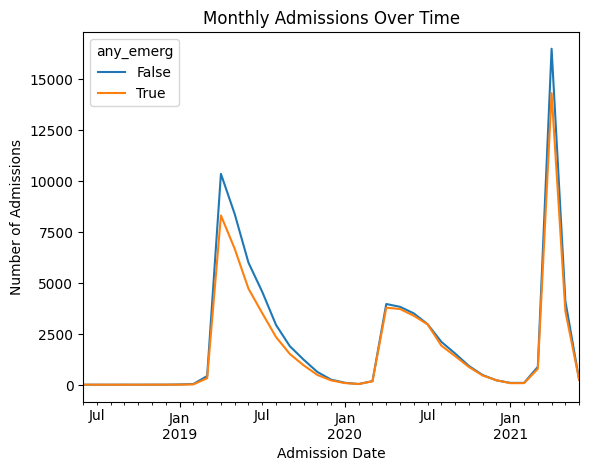

In [3]:
df["month"] = df["adm"].dt.to_period("M")
admissions_trend = df.groupby(["month", "any_emerg"])["spell_id"].count().unstack("any_emerg", fill_value=0)

admissions_trend.plot(title="Monthly Admissions Over Time")
plt.ylabel("Number of Admissions")
plt.xlabel("Admission Date")


Text(0.5, 1.0, 'Length of Stay Distribution')

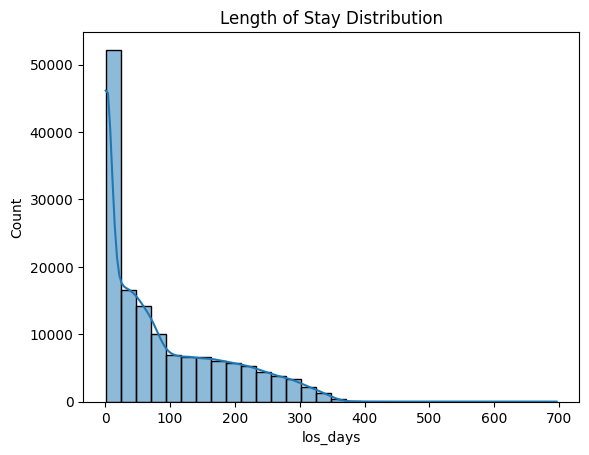

In [4]:
sns.histplot(df["los_days"].dropna(), bins=30, kde=True)
plt.title("Length of Stay Distribution")

Text(0.5, 1.0, 'LOS by Emergency Status')

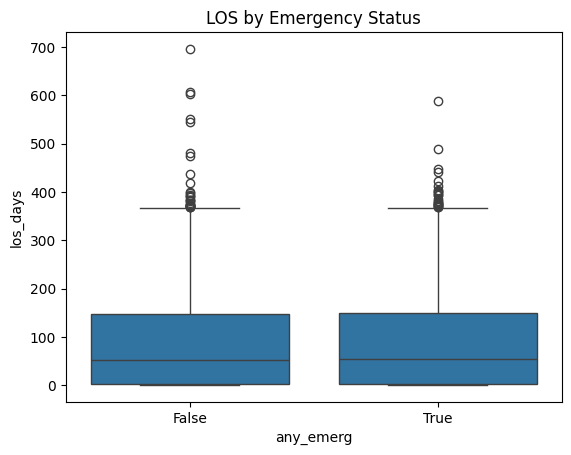

In [5]:
sns.boxplot(x="any_emerg", y="los_days", data=df)
plt.title("LOS by Emergency Status")

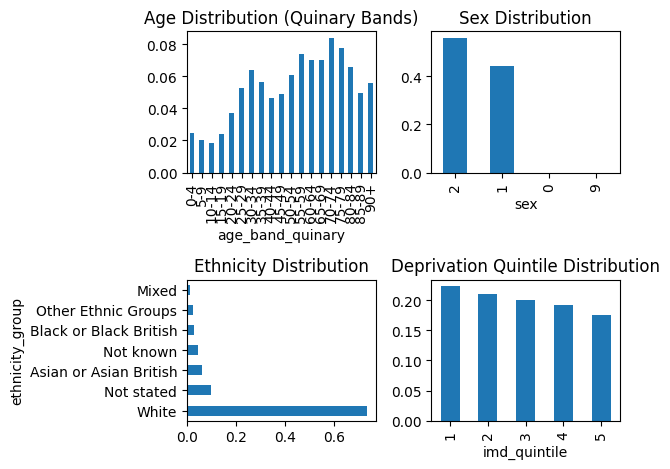

In [6]:
fig, axes = plt.subplots(2, 2)

df["age_band_quinary"].value_counts(normalize=True).sort_index().plot(
    kind="bar", 
    ax=axes[0, 0],
    title="Age Distribution (Quinary Bands)"
)

df["sex"].value_counts(normalize=True).plot(
    kind="bar",
    ax=axes[0, 1],
    title="Sex Distribution"
)

df["ethnicity_group"].value_counts(normalize=True).plot(
    kind="barh",
    ax=axes[1, 0],
    title="Ethnicity Distribution"
)

df["imd_quintile"].value_counts(normalize=True).sort_index().plot(
    kind="bar", 
    ax=axes[1, 1],
    title="Deprivation Quintile Distribution"
)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Admissions by IMD Quintile')

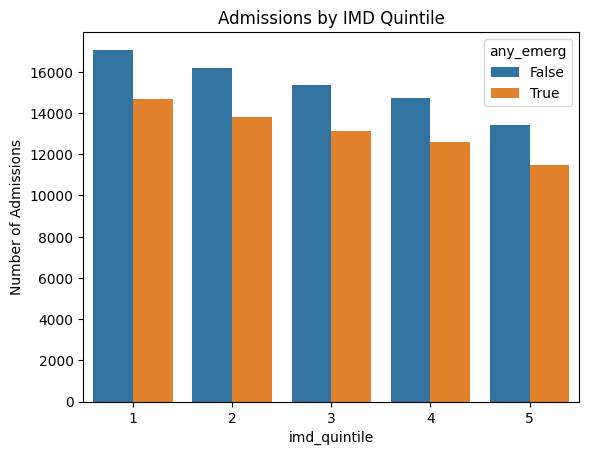

In [7]:
adm_by_imd = df.groupby(["imd_quintile", "any_emerg"])["spell_id"].count().reset_index()

sns.barplot(adm_by_imd, x="imd_quintile", y="spell_id", hue="any_emerg")
plt.ylabel("Number of Admissions")
plt.title("Admissions by IMD Quintile")


C:\Users\khize\AppData\Local\Temp\ipykernel_15324\815466078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adm_by_eth = df.groupby(["ethnicity_group", "any_emerg"])["spell_id"].count().reset_index()


Text(0.5, 1.0, 'Admissions by Ethnic Group')

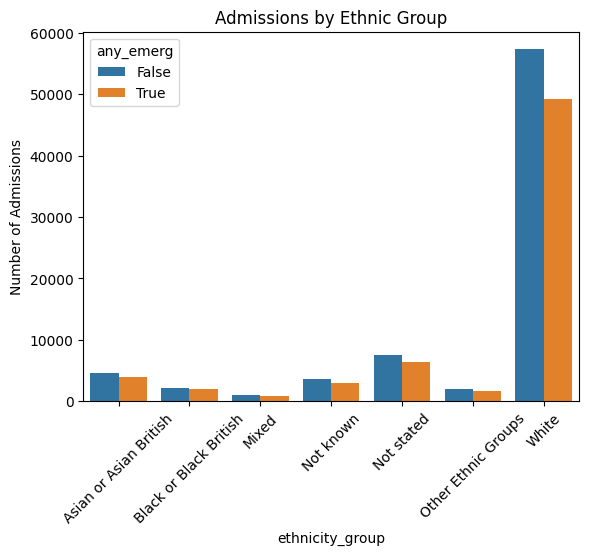

In [12]:
adm_by_eth = df.groupby(["ethnicity_group", "any_emerg"])["spell_id"].count().reset_index()

sns.barplot(adm_by_eth, x="ethnicity_group", y="spell_id", hue="any_emerg")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.title("Admissions by Ethnic Group")

Text(0.5, 1.0, 'Mean LOS by IMD Quintile')

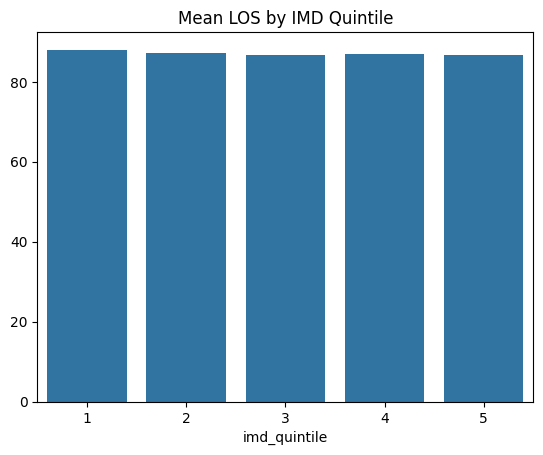

In [9]:
los_by_imd = df.groupby("imd_quintile")["los_days"].mean()

sns.barplot(x=los_by_imd.index, y=los_by_imd.values)
plt.title("Mean LOS by IMD Quintile")

C:\Users\khize\AppData\Local\Temp\ipykernel_15324\2604898104.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  los_by_ethnicity = df.groupby("ethnicity_group")["los_days"].mean()


Text(0.5, 1.0, 'Mean LOS by Ethnicity Group')

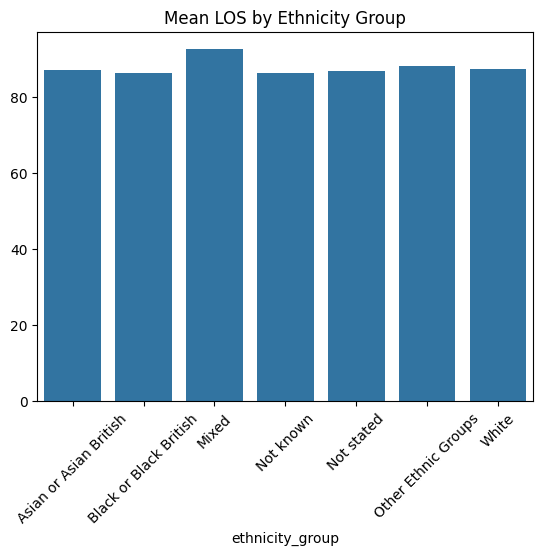

In [10]:
los_by_ethnicity = df.groupby("ethnicity_group")["los_days"].mean()

sns.barplot(x=los_by_ethnicity.index, y=los_by_ethnicity.values)
plt.xticks(rotation=45)
plt.title("Mean LOS by Ethnicity Group")

<Axes: title={'center': 'Respiratory Group Breakdown'}, xlabel='respiratory_group'>

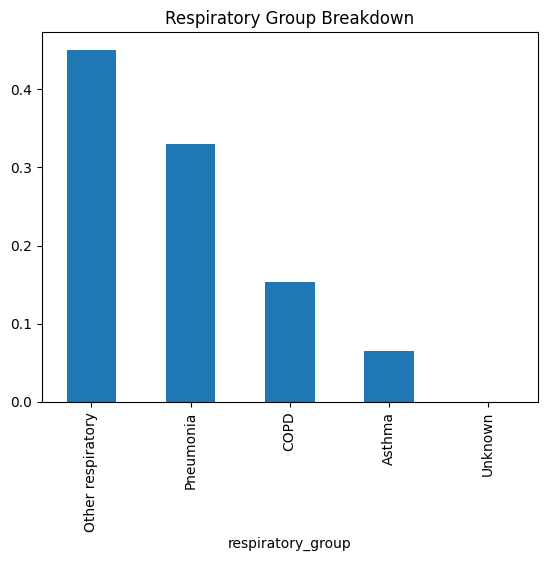

In [ ]:
df["respiratory_group"].value_counts(normalize=True).plot(kind="bar", title="Respiratory Group Breakdown")

Text(0.5, 1.0, 'LOS by Respiratory Group')

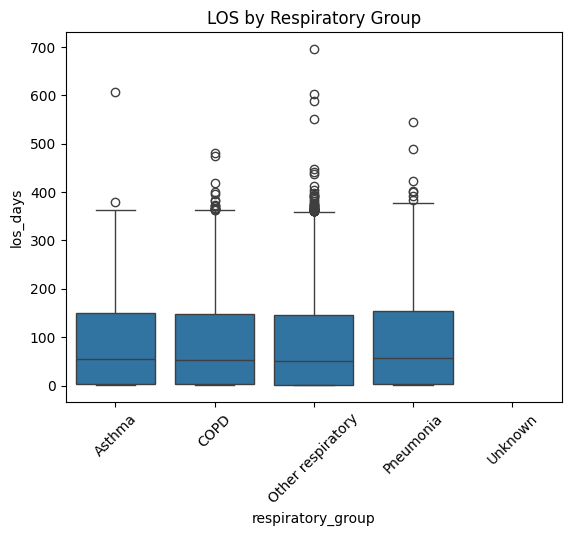

In [14]:
sns.boxplot(x="respiratory_group", y="los_days", data=df)
plt.xticks(rotation=45)
plt.title("LOS by Respiratory Group")